In [1]:
import os

import cv2
import torch
from PIL import Image
import numpy as np 
import pandas as pd 
import matplotlib
import matplotlib.pyplot as plt 
from matplotlib.patches import Rectangle
from tqdm import tqdm
import wandb
from datetime import datetime

import tonic
import snntorch as snn
from snntorch import surrogate
import snntorch.functional as SF

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from torchinfo import summary


# clean gpu memory when starting a new evaluation.
torch.cuda.empty_cache()

GPU_DEVICE = 3
os.environ['CUDA_VISIBLE_DEVICES'] = str(GPU_DEVICE)
os.environ['CUDA_LAUNCH_BLOCKING'] = str(1)

assert torch.cuda.is_available()

DEVICE = torch.device(f"cuda") if torch.cuda.is_available() else torch.device("cpu")
assert DEVICE == torch.device(f"cuda"), f'{DEVICE}'

In [2]:
def seed_everything(seed=42):
    #random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    #torch.backends.cudnn.deterministic = True
    #torch.backends.cudnn.benchmark = False
    #os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"Global seed set to {seed}")
    

def create_gif(images, output_gif_path, duration=100):
     images = [Image.fromarray(np.stack([img, img, img], axis=-1)) for img in images]
     # Save as GIF
     images[0].save(output_gif_path,
                    save_all=True,
                    append_images=images[1:],
                    duration=duration,
                    loop=0 # 0 means infinite loop
                    )

In [3]:
DATA_PATH = 'data/recorded_DVS_data_with_ROI/'
event_lst = sorted([f for f in os.listdir(DATA_PATH) if '.npy' in f or '.npz' in f])
W, H      = 346, 260 
CLASS_LST = ['mug', 'bottle', 'coffee_cup']

# create data frame
all_samples = []

for obj in CLASS_LST:
    path = os.path.join(DATA_PATH, obj)
    event_lst = sorted([f for f in os.listdir(path) if '.npy' in f or '.npz' in f])
    print(len(event_lst))
    
    for i, file in enumerate(event_lst):
        file_path = os.path.join(DATA_PATH, obj, file)
        data = np.load(file_path, allow_pickle=True) 
        cx = int(data["cx"].item()) #x coordinate of ROI center
        cy = int(data["cy"].item()) #y coordinate of ROI center
        roi_size = int(data["roi_size"].item()) 
        
        all_samples.append({'label': obj, 'id': i, 'roi_cx': cx, 'roi_cy': cy, 
                            'roi_size': roi_size, 'file': file})

df = pd.DataFrame.from_records(all_samples)
df['category'] = df.apply(lambda x: CLASS_LST.index(x['label']), axis=1)
df.head()

200
200
400


,label,id,roi_cx,roi_cy,roi_size,file,category
0,mug,0,104,163,142,mug_1_00086_full.npz,0
1,mug,1,108,151,152,mug_1_00087_full.npz,0
2,mug,2,110,154,170,mug_1_00089_full.npz,0
3,mug,3,112,161,171,mug_1_00092_full.npz,0
4,mug,4,115,169,164,mug_1_00093_full.npz,0


In [37]:
DATA_PATH = 'data/events_converted_from_3D_models/'
CLASS_LST = sorted([f for f in os.listdir(DATA_PATH)])
W, H      = 346, 260 
print(CLASS_LST)

# create data frame
all_samples = []

for obj in CLASS_LST:
    path = os.path.join(DATA_PATH, obj)
    event_lst = sorted([f for f in os.listdir(path) if '.npy' in f or '.npz' in f])
    print(len(event_lst))
    
    for i, file in enumerate(event_lst):
        file_path = os.path.join(DATA_PATH, obj, file)
        data = np.load(file_path, allow_pickle=True) 
        print(data)
        cx = int(data["cx"].item()) #x coordinate of ROI center
        cy = int(data["cy"].item()) #y coordinate of ROI center
        roi_size = int(data["roi_size"].item()) 
        
        all_samples.append({'label': obj, 'id': i, 'roi_cx': cx, 'roi_cy': cy, 
                            'roi_size': roi_size, 'file': file})

df = pd.DataFrame.from_records(all_samples)
df['category'] = df.apply(lambda x: CLASS_LST.index(x['label']), axis=1)
df.head()

['apple', 'bottle', 'mug', 'paper_cup']
216
[(248, 238, 0,     0) ( 77,  68, 1,     1) (111, 108, 1,     2) ...
 (126, 151, 0, 34997) (  4,  74, 1, 34998) ( 92, 140, 1, 34999)]


ValueError: no field of name cx

600
data/recorded_DVS_data_with_ROI/mug/mug_1_00086_full.npz
mug 0 (35, 48, 48)


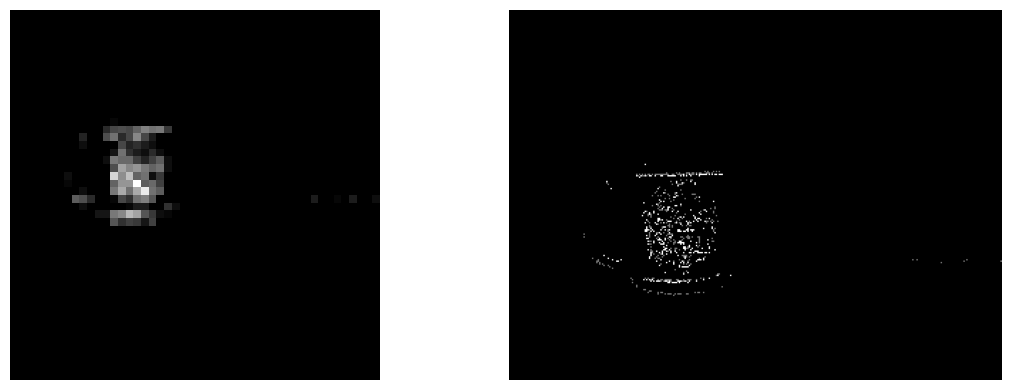

In [40]:
class DVSDataset(Dataset):
    """Custom DVS dataset for RoDeO
    """

    def __init__(self, dataset, data_path, frame_size=(260, 346), target_size=(48, 48),
                 time_bins=35, create_img=False, transform=None):
        
        self.data_path = data_path
        self.dataset = dataset
        self.create_img = create_img
        self.frame_size = frame_size
        self.time_bins = time_bins
        fsize = np.max(frame_size).astype(int)
        self.tonic_transform = tonic.transforms.Compose([#tonic.transforms.Denoise(filter_time=10000), 
                                                         #tonic.transforms.MergePolarities(),
                                                         tonic.transforms.Downsample(sensor_size=(346, 346, 1), target_size=target_size),
                                                         tonic.transforms.ToFrame(sensor_size=(*target_size, 1), n_time_bins=time_bins)])
        self.transform = transform
        
        
    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        
        label = self.dataset.iloc[idx].label
        file = self.dataset.iloc[idx].file 
        cat = self.dataset.iloc[idx].category
        fpath = os.path.join(self.data_path, label+'/', file)
        print(fpath)
        
        # Load data 
        data = np.load(fpath, allow_pickle=True) 
        events = data["events"].item() if data["events"].ndim == 0 else data["events"] 
        xs = events["x"].astype(np.int32) #x coordinates of events
        ys = events["y"].astype(np.int32) #y coordinates of events
        pol = np.where(events["polarity"], events["polarity"], 1).astype('i1') # turn all polarities to positive
        t = events["timestamp"].astype(np.int64)
        
        # clip to frame size
        mask = (xs >= 0) & (xs < self.frame_size[1]) & (ys >= 0) & (ys < self.frame_size[0]) 

        # Stack into a structured array for tonic
        stack_events = np.rec.fromarrays([xs[mask], ys[mask], pol, t], dtype=[('x', '<i2'), ('y', '<i2'), ('p', 'i1'), ('t', '<i8')])

        # turn events into frames with tonic 
        frame = self.tonic_transform(stack_events).squeeze()
        #frame = np.moveaxis(frame.squeeze(), 0, -1) # reshape frame for torchvision transforms
        
        if self.transform: 
            frame = self.transform(frame)
        
        if self.create_img:  
            pol = events["polarity"].astype(bool) 
            img = np.zeros((*self.frame_size, 3), dtype=np.uint8)
            img[ys[mask &  pol], xs[mask &  pol]] = (255, 255, 255)   # positive: white
            img[ys[mask & ~pol], xs[mask & ~pol]] = (120, 120, 120)   # negative: grey
        else: 
            img = None
            
        return {'img': img, 'frame': frame, 'cat': int(cat), 'label': label, 'file': file, 'path': fpath}


dataset = DVSDataset(df, DATA_PATH, transform=None, create_img=True)
print(len(dataset))

sample = dataset.__getitem__(0)
print(sample['label'], sample['cat'], sample['frame'].shape)

# plot frame and origin input 
f, (ax1, ax2) = plt.subplots(1, 2, sharey=False, figsize=(12, 4))
ax1.imshow(sample['frame'].sum(axis=0), cmap='gray')
ax1.axis('off')

ax2.imshow(sample['img'])
ax2.axis('off')

f.tight_layout()
plt.show()

## Read CALTECH 256

```python
%%time
import h5py

filename = "data/INI_Caltech256_10fps_20160424.hdf5"
data_lst = []
with h5py.File(filename, "r") as f:

    #f.visit(print)  
    object_keys = f.keys()
    for k in object_keys:
        sample_lst = f[k].keys()
        
        for s in sample_lst:
            data_x = f[k][s]['x_pos'][:]
            data_y = f[k][s]['y_pos'][:]
            data_t = f[k][s]['timestamps'][:]
            data_pol = f[k][s]['pol'][:]
            
            data = {'object': k, 'sample': s, 'x_pos': data_x, 'y_pos': data_y, 
                    'timestamps': data_t, 'pol': data_pol}
            data_lst.append(data)
        
    
df = pd.DataFrame.from_records(data_lst)
df['category'] = df.apply(lambda x: int(x['object'].split('.')[0]), axis=1)
df['label'] = df.apply(lambda x: str(x['object'].split('.')[1]), axis=1)
df['sample'] = df['sample'].map(lambda x: int(x.split('_')[-1]))
del df['object']
df.to_pickle('Caltech_256_DVS.pkl')
df.head() 
```

In [4]:
df = pd.read_pickle('data/Caltech_256_DVS.pkl')
print('Number of samples: ', len(df))
df.head()

Number of samples:  30607


,sample,x_pos,y_pos,timestamps,pol,category,label
0,1,"[192, 146, 106, 37, 140, 80, 87, 173, 146, 187...","[109, 71, 29, 101, 36, 143, 135, 88, 50, 153, ...","[288080, 288235, 288387, 288692, 289515, 28971...","[True, True, True, True, True, True, True, Tru...",1,ak47
1,2,"[152, 149, 224, 76, 80, 63, 213, 38, 214, 135,...","[53, 116, 18, 114, 8, 173, 102, 23, 104, 28, 3...","[299585, 301461, 301791, 304118, 304755, 30783...","[True, True, True, True, True, True, True, Tru...",1,ak47
2,3,"[80, 128, 94, 57, 113, 105, 91, 96, 166, 93, 1...","[144, 40, 149, 37, 62, 44, 59, 32, 89, 142, 12...","[299761, 299961, 300369, 300463, 300466, 30046...","[True, True, True, True, True, True, True, Tru...",1,ak47
3,4,"[208, 40, 94, 191, 104, 158, 126, 138, 48, 214...","[97, 142, 137, 96, 136, 29, 56, 147, 75, 121, ...","[301202, 302304, 302330, 304919, 304952, 30559...","[True, True, True, True, True, True, True, Tru...",1,ak47
4,5,"[108, 154, 220, 162, 215, 124, 132, 86, 220, 2...","[122, 179, 84, 126, 31, 135, 155, 104, 12, 73,...","[286731, 286909, 288470, 291223, 291830, 29219...","[True, True, True, True, True, True, True, Tru...",1,ak47


In [5]:
import json

# Open a file in write mode ('w')
with open("caltech256_classes.json", "w") as file:
    json.dump(list(df.label.unique()), file)

### Reduce dataset to 15 classes
```python
lst = ['beer-mug', 'coffee-mug', 'bowling-ball', 'cake', 'cereal-box', 'coin', 'computer-mouse', 
       'fern', 'goldfish', 'hot-dog', 'mushroom', 'penguin', 'pyramid', 'teddy-bear', 'tomato']

df = df.loc[df.label.isin(lst)].reset_index(drop=True)
df['category'] = df.label.apply(lambda x: lst.index(x))

print('Number of classes: ', len(df.label.unique()), df.category.unique())
df.to_pickle('DVS_Caltech15.pkl')
df.head()
```

### Create GIF
```python 
idx = 1210 
data = df.iloc[idx]

frames = np.zeros(((max(data.timestamps) // 30000) +1, 180, 240))
for (x, y, pol, time) in zip(data.x_pos, data.y_pos, data.pol, data.timestamps): 
    
    t = time // 30000  
    frames[t, y, x] = pol 
    
frames = frames * 255
create_gif(frames.astype(np.uint8), f'caltech256-{idx}.gif') 
```

In [6]:
def roi_to_spike_array(roi_events_down, roi_size=48):
    """
    Convert downscaled ROI events to spike array for SpiNNaker
    Returns:
        List of tuples (timestamp_ms, neuron_id)
    """
    if len(roi_events_down) == 0:
        return []

    timestamps = roi_events_down['t']
    x_coords = roi_events_down['x']
    y_coords = roi_events_down['y']

    t_min = timestamps.min()
    timestamps_ms = ((timestamps - t_min) / 1000.0).astype(np.float64)

    # Map coordinates to 1D neuron IDs 
    # neuron_id = y * roi_size + x
    neuron_ids = (y_coords * roi_size + x_coords).astype(np.int32)
    spikes = [(timestamps_ms[i], neuron_ids[i]) for i in range(len(roi_events_down))]

    spikes.sort(key=lambda x: x[0])
    return spikes

class CaltechDataset(Dataset):
    """Caltech 256 DVS Dataset for object recognition
    see DVSACT16 for details https://sensors.ini.ch/datasets
    """

    def __init__(self, dataset, img_size=(180, 240), time_bins=35, transform=None):
        
        self.dataset = dataset
        self.img_size = img_size
        self.time_bins = time_bins
        self.dimension = img_size[0] * img_size[1]
        self.pos_id = np.arange(img_size[0] * img_size[1]).reshape(img_size[0], img_size[1])
        self.tonic_transform = tonic.transforms.Compose([#tonic.transforms.Denoise(filter_time=10000), 
                                                         tonic.transforms.ToFrame(sensor_size=(*img_size[::-1], 1), n_time_bins=time_bins)])
        
        
        self.transform = transform
        
        
    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        data = self.dataset.iloc[idx]
        pol, time = data.pol, data.timestamps 
        cat, label = data.category, data.label
        
        x_col = data.x_pos.astype('<i2')
        y_col = self.img_size[0] - data.y_pos.astype('<i2') - 1 # flip y-axis
        p_col = np.where(data.pol, data.pol, 1).astype('i1') # turn all polarities to positive
        t_col = data.timestamps.astype('<i8')

        # Stack them into a structured array
        events = np.rec.fromarrays([x_col, y_col, p_col, t_col], dtype=[('x', '<i2'), ('y', '<i2'), ('p', 'i1'), ('t', '<i8')])
        
        # turn events into frames with tonic 
        frame = self.tonic_transform(events)
        frame = np.moveaxis(frame.squeeze(), 0, -1) # reshape frame for torchvision transforms
        
        if self.transform: 
            frame = self.transform(frame)
            
        return {'frame': frame, 'cat': int(cat)-1, 'label': label}

ak47 0 torch.Size([35, 48, 48])


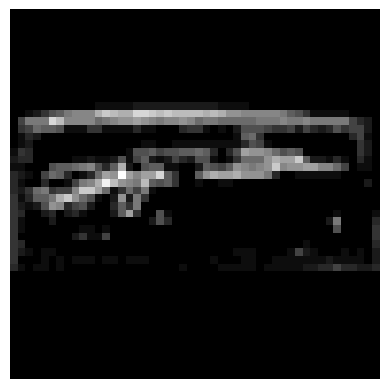

In [7]:
T = transforms.Compose([transforms.ToTensor(),
                        transforms.Pad((0, 30, 0, 30)), #left, top, right, bottom
                        transforms.Resize((48, 48), interpolation=transforms.InterpolationMode.BILINEAR)])

dataset = CaltechDataset(df, transform=T)
sample = dataset.__getitem__(10)
print(sample['label'], sample['cat'], sample['frame'].shape)

plt.imshow(sample['frame'].float().sum(axis=0), cmap='gray')
plt.axis('off')
plt.show()

## Define Model 

In [8]:
class TinyConvSNN_24_FC(nn.Module):
    def __init__(self, H=48, W=48, n_classes=257, beta=0.95, num_steps=100, dropout_p=0.0, fc_hidden=512):
        super().__init__()
        self.H, self.W = H, W
        self.n_classes = n_classes
        self.num_steps = num_steps
        
        spike_grad = surrogate.fast_sigmoid(slope=25)
        
        # Conv layer (L1)
        self.conv1 = nn.Conv2d(1, 4, kernel_size=5, stride=6, padding=0, bias=False)
        
        # Hidden layer (L2)
        self.fc1 = nn.Linear(256, fc_hidden, bias=False)  
        self.lif_fc1 = snn.Leaky(beta=beta, spike_grad=spike_grad, learn_beta=False)  
        self.dropout_fc1 = nn.Dropout(p=dropout_p)  
        
        # Readout layer (L3)
        self.readout = nn.Linear(fc_hidden, n_classes, bias=False)  
        
        # LIF neurons
        self.lif1 = snn.Leaky(beta=beta, spike_grad=spike_grad, learn_beta=False)
        self.lif_out = snn.Leaky(beta=beta, spike_grad=spike_grad, learn_beta=False)
        
        self.dropout1 = nn.Dropout(p=dropout_p)
        self.dropout_readout = nn.Dropout(p=dropout_p)
        
        self._initialize_weights()
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.xavier_normal_(m.weight, gain=1.0)
    
    def forward(self, x):
        T, B, _ = x.shape
        x = x.view(T, B, 1, self.H, self.W)
        
        assert 'cuda' in str(x.device)
        
        mem1 = self.lif1.init_leaky().to(x.device)
        mem_fc1 = self.lif_fc1.init_leaky().to(x.device)  
        memo = self.lif_out.init_leaky().to(x.device)
        
        fmap1_rec = []
        spk_out_rec = []
        for t in range(T):
            xt = x[t]
            # Conv layer
            cur1 = self.conv1(xt)
            spk1, mem1 = self.lif1(cur1, mem1)
            spk1 = self.dropout1(spk1)
            
            fmap1_rec.append(spk1)
            
            # Flatten
            feat = spk1.flatten(1)  # [B, 256]
            # Hidden FC layer 
            cur_fc1 = self.fc1(feat)
            spk_fc1, mem_fc1 = self.lif_fc1(cur_fc1, mem_fc1)
            spk_fc1 = self.dropout_fc1(spk_fc1)
            # Readout layer
            spk_fc1_drop = self.dropout_readout(spk_fc1)
            cur_out = self.readout(spk_fc1_drop)
            spk_out, memo = self.lif_out(cur_out, memo)
            
            assert 'cuda' in str(spk_fc1_drop.device)
            assert 'cuda' in str(cur_out.device)
            assert 'cuda' in str(spk_out.device)
            assert 'cuda' in str(memo.device)
            
            spk_out_rec.append(spk_out)
        
        return torch.stack(spk_out_rec, dim=0), [torch.stack(fmap1_rec, dim=0)]
    
    @torch.no_grad()
    def predict(self, x):
        # x: [T,B,2304]
        spk = self.forward(x)
        counts = spk.sum(0)              # [B,26]
        return counts.argmax(dim=1)
    
    
class SpikingObjectClassifier(nn.Module):
    
    def __init__(self, in_channels=1, img_size=(48, 48), hidden=[1, 2, 3],
                 hidden_channels=4, kernel=3, stride=1, padding=1,
                 spike_grad=surrogate.atan(), beta=0.95, num_steps=35, lif_threshold=0.5,
                 n_classes=257, dropout=None):
        super().__init__()
        
        self.num_steps = num_steps
        self.dropout = True if dropout else False
        
        self.conv1 = nn.Conv2d(1, hidden_channels*hidden[0], kernel, stride, padding, bias=False)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=spike_grad, threshold=lif_threshold, 
                              learn_threshold=True, learn_beta=False)
        
        self.conv2 = nn.Conv2d(hidden_channels*hidden[0], hidden_channels*hidden[1], 
                               kernel, stride*hidden[2], padding, bias=False)
        
        self.lif2 = snn.Leaky(beta=beta, spike_grad=spike_grad, threshold=lif_threshold, 
                              learn_threshold=True, learn_beta=False)
        
        self.conv3 = nn.Conv2d(hidden_channels*hidden[1], hidden_channels*hidden[2], 
                               kernel, stride*hidden[2], padding, bias=False)
        
        self.lif3 = snn.Leaky(beta=beta, spike_grad=spike_grad, threshold=lif_threshold, 
                              learn_threshold=True, learn_beta=False)
        
        self.pool = nn.AvgPool2d(kernel_size=2) # maxpooling is unsuitable for SNNs
        
        # use dropout as regularization 
        self.dropout1 = nn.Dropout(p=dropout) if dropout else None
        self.dropout2 = nn.Dropout(p=dropout) if dropout else None
        self.dropout_linear = nn.Dropout(p=dropout) if dropout else None
        self.dropout_out = nn.Dropout(p=dropout) if dropout else None

            
        # flatten before linear layer
        self.fc = nn.Flatten()
        
        hidden_dim = self._get_hidden_dim(torch.ones(1, num_steps, *img_size))
        
        # define classifier
        
        self.classifier = nn.Linear(hidden_dim, n_classes, bias=False)
        self.lif_out = snn.Leaky(beta=beta, spike_grad=spike_grad, threshold=lif_threshold, 
                                 learn_threshold=True, learn_beta=False)
        
        #self._initialize_weights()
        
    def _get_hidden_dim(self, x):
        cur1 = self.conv1(x[:, 0].unsqueeze(1))
        cur2 = self.conv2(cur1)
        cur3 = self.conv3(cur2)
        out = self.fc(cur3)
        return out.shape[-1]
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.xavier_normal_(m.weight, gain=1.0)
    
    def forward(self, x):
        B, T, H, W = x.shape
        
        # Initialize hidden states and outputs at t=0
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()
        mem_out = self.lif_out.init_leaky()
        
        fmap1_rec = []
        fmap2_rec = []
        fmap3_rec = []
        
        spk_out_rec = []
        mem_out_rec = []
        for step in range(T):
            
            # conv layer 1
            #print(x[:, step].unsqueeze(1).shape)
            cur1 = self.conv1(x[:, step].unsqueeze(1))
            spk1, mem1 = self.lif1(cur1, mem1)
            spk1 = self.dropout1(spk1) if self.dropout else spk1
            fmap1_rec.append(spk1)
            
            # conv layer 2
            cur2 = self.conv2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            spk2 = self.dropout2(spk2) if self.dropout else spk2
            fmap2_rec.append(spk2)
            
            # conv layer 3
            cur3 = self.conv3(spk2)
            spk3, mem3 = self.lif3(cur3, mem3)
            fmap3_rec.append(spk3)
            
            # classifier
            spk_out = self.fc(spk3)
            spk_out = self.classifier(spk_out)
            spk_out, mem_out = self.lif_out(spk_out, mem_out)
            spk_out = self.dropout_out(spk_out) if self.dropout else spk_out
            
            spk_out_rec.append(spk_out)
            mem_out_rec.append(mem_out)
        
        return torch.stack(spk_out_rec, dim=0), torch.stack(mem_out_rec, dim=0), [torch.stack(fmap1_rec, dim=0), torch.stack(fmap2_rec, dim=0), torch.stack(fmap3_rec, dim=0)]

In [9]:
#model = TinyConvSNN_24_FC(H=48, W=48, n_classes=257)
model = SpikingObjectClassifier(img_size=(48, 48), n_classes=257, hidden_channels=4)
summary(model, input_size=(1, 1, 48, 48))

Layer (type:depth-idx)                   Output Shape              Param #
SpikingObjectClassifier                  [1, 1, 257]               --
├─Conv2d: 1-1                            [1, 4, 48, 48]            36
├─Leaky: 1-2                             [1, 4, 48, 48]            1
├─Conv2d: 1-3                            [1, 8, 16, 16]            288
├─Leaky: 1-4                             [1, 8, 16, 16]            1
├─Conv2d: 1-5                            [1, 12, 6, 6]             864
├─Leaky: 1-6                             [1, 12, 6, 6]             1
├─Flatten: 1-7                           [1, 432]                  --
├─Linear: 1-8                            [1, 257]                  111,024
├─Leaky: 1-9                             [1, 257]                  1
Total params: 112,216
Trainable params: 112,216
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.30
Input size (MB): 0.01
Forward/backward pass size (MB): 0.19
Params size (MB): 0.45
Estimated Total Size (MB): 

In [10]:
DEBUG = False
RANDOM_SEED = 7
seed_everything(RANDOM_SEED)

LR = 0.002
EPOCHS = 200
BATCH_SIZE = 512
DROPOUT = 0.2
BETA = 0.97
LIF_THRESHOLD = 0.3
OPTIMIZER = 'AdamW'
SURROGATE = 'atan'
HIDDEN_CHANNELS = 4

T = transforms.Compose([transforms.ToTensor(),
                        transforms.Pad((0, 30, 0, 30)), #left, top, right, bottom
                        transforms.Resize((48, 48), interpolation=transforms.InterpolationMode.BILINEAR)])

dataset = CaltechDataset(df, transform=T)

train_set, val_set = torch.utils.data.random_split(dataset, [int(len(dataset) * 0.8), len(dataset) - int(len(dataset) * 0.8)])
val_set, test_set = torch.utils.data.random_split(val_set, [int(len(val_set) * 0.8), len(val_set) - int(len(val_set) * 0.8)])
print('Training samples: ',len(train_set))
print('Validation samples: ', len(val_set))
print('Test samples: ', len(test_set))

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=16)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE//2, shuffle=False, num_workers=8)

N_CLASSES = len(df.category.unique())
print('Number of classes: ', N_CLASSES)

x = datetime.now()
TIME_STAMP = x.strftime("%d%b%y-%H%M%S")
MODEL_NAME = f"Spiking-RoDeO_{N_CLASSES}_{RANDOM_SEED}_{TIME_STAMP}"
print(MODEL_NAME)

spike_grad = surrogate.fast_sigmoid(slope=25) if SURROGATE == 'fast_sigmoid' else surrogate.atan()


if not DEBUG:
    # Initialize wandb 
    wandb.init(project='RoDeO',
               name=MODEL_NAME,
               config={'optimizer': OPTIMIZER, 
                       'lr': LR,
                       'hidden_channels': HIDDEN_CHANNELS,
                       'n_classes': N_CLASSES,
                       'lif_threshold': LIF_THRESHOLD,
                       'dropout': DROPOUT,
                       'beta': BETA,
                       'surrogate': SURROGATE,
                       'loss': 'CrossEntropy',
                       'epochs': EPOCHS,
                       'batch_size': BATCH_SIZE})

best_val_acc = 0.05
best_model_path = f'results/{MODEL_NAME}.pth'

model = SpikingObjectClassifier(img_size=(48,48), n_classes=N_CLASSES, hidden_channels=HIDDEN_CHANNELS, 
                                beta=BETA, spike_grad=spike_grad, dropout=DROPOUT, lif_threshold=LIF_THRESHOLD)
model.to(DEVICE)

# initialize loss function & optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = getattr(torch.optim, OPTIMIZER)(model.parameters(), lr=LR)

for epoch in range(EPOCHS):
    
    train_loss = []
    train_accuracy = []
    train_grad_norms = []
    
    model.train()
    pbar = tqdm(train_loader, desc=f'Epoch {epoch}', unit='batch', ncols=115)
    for i, sample in enumerate(pbar):
        
        #nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) 
        optimizer.zero_grad()
        
        B, T, H, W = sample['frame'].shape
        frames = sample['frame'].float().view(B, T, H, W).to(DEVICE)
        cats = sample['cat'].to(DEVICE) 

        spk_out, mem_rec, _ = model(frames)
        
        logits = spk_out.sum(0) # [B,C]
        probs = torch.softmax(logits, dim=1)
        loss = loss_fn(probs, cats)
        
        
        loss.backward()
        
        total_norm = 0
        for p in model.parameters():
            if p.grad is not None:
                param_norm = p.grad.data.norm(2)
                total_norm += param_norm.item() ** 2
        total_norm = total_norm ** 0.5
        train_grad_norms.append(total_norm)
        
        optimizer.step()
        
        # log train loss 
        train_loss.append(loss.item())
        
        # compute train accuracy
        preds = logits.argmax(dim=1)
        acc = (preds == cats).sum().item()
        train_accuracy.append(acc / B)
        
        pbar.set_postfix(loss=f'{loss.item():.3f}', acc=f'{acc / B:.2%}')
    
    #pbar.set_postfix({'avg_loss':f'{np.mean(train_loss):.3f}', 'avg_acc':f'{np.mean(train_accuracy):.2%}'})
    print(f'Average training loss: {np.mean(train_loss):.2f} - accuracy {np.mean(train_accuracy):.2%}')
    print(f"Current LR: {optimizer.param_groups[0]['lr']}")
    
    # log results / gradients / weights to wandb
    if not DEBUG:
        log_layers = ['conv1.weight', 'conv2.weight', 'classifier.weight']
        
        # only log once per epoch for faster training
        log_dict = {'loss': np.mean(train_loss), 'accuracy': np.mean(train_accuracy), 
                    'gradient/total_norm': np.mean(train_grad_norms), 'epoch': epoch}
        
        for name, param in model.named_parameters():
            if param.grad is not None:
                log_dict[f'gradient/{name}_norm'] = param.grad.norm().item()
                
            if name in log_layers:
                log_dict[f'weights/{name.split(".")[0]}'] = wandb.Histogram(param.detach().cpu().numpy())
        
        wandb.log(log_dict)    
    
    # Validation
    model.eval()
    val_loss = []
    val_accuracy = []
    with torch.no_grad():
        for i, sample  in enumerate(val_loader):
            B, T, H, W = sample['frame'].shape
            frames = sample['frame'].float().to(DEVICE)
            cats = sample['cat'].to(DEVICE) 

            spk_out, mem_rec, _ = model(frames)
            
            # compute loss
            """
            loss = loss_fn(spk_out, cats)
            logits = spk_out.sum(0) # [B,C]
            """
            
            logits = spk_out.sum(0) # [B,C]
            probs = torch.softmax(logits, dim=1)
            loss = loss_fn(probs, cats)
        
            val_loss.append(loss.item())
            
            # compute validation accuracy
            preds = logits.argmax(dim=1)
            acc = (preds == cats).sum().item()
            val_accuracy.append(acc / B)
            
    print(f'validation loss: {np.mean(val_loss):.2f} - accuracy {np.mean(val_accuracy):.2%}')
    if not DEBUG:
        # log validation metrics to wandb
        wandb.log({'val_loss': np.mean(val_loss), 'val_accuracy': np.mean(val_accuracy), 'epoch': epoch}) 
    
        # save best model
        if np.mean(val_accuracy) > best_val_acc:
            best_val_acc = np.mean(val_accuracy)
            torch.save(model.state_dict(), best_model_path)
            print('Saved model to:', best_model_path)
        
        
if not DEBUG:
    wandb.finish() 

Global seed set to 7
Training samples:  24485
Validation samples:  4897
Test samples:  1225
Number of classes:  257
Spiking-RoDeO_257_7_25Jun26-195451


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/penzkofer/.netrc.
wandb: Currently logged in as: apenzko to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 0: 100%|███████████████████████████████████████████| 48/48 [00:35<00:00,  1.33batch/s, acc=4.04%, loss=5.513]

Average training loss: 5.52 - accuracy 3.36%
Current LR: 0.002


validation loss: 5.51 - accuracy 4.75%


...

validation loss: 5.42 - accuracy 14.02%


Epoch 199: 100%|████████████████████████████████████████| 48/48 [00:28<00:00,  1.70batch/s, acc=28.27%, loss=5.276]

Average training loss: 5.30 - accuracy 25.90%
Current LR: 0.002


validation loss: 5.41 - accuracy 14.56%
Saved model to: results/Spiking-RoDeO_257_7_25Jun26-195451.pth


accuracy,▁▂▂▃▄▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇█████████
epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇█
gradient/classifier.weight_norm,▂▄▃▂▃▂▂▄▂▂▂▃█▃▃▁▂▄▁▃▂▁▂▂▂▃▃▃▂▁▁▂▂▃▃▂▄▂▅▃
gradient/conv1.weight_norm,▄▇▅▆▆▃▆▅▃▆▄▃▆▂▇▄▅▂▅▄█▄▃▃▄▅▂▃▃▄▅▂▄▁▃▂▄▄▂▂
gradient/conv2.weight_norm,▁▃▄▁▄▃▂▅▁▃▂▄▂▇▁█▃▄▅▃▂▄▁▃▄▂▂▂▅▂▁▂▁▂▄▃▃▂▂▂
gradient/conv3.weight_norm,▁▂▂▂▂▃▃▂▂▂▁▂█▃▂▄▁▃▅▇▄▄▂▅▃▃▂▂▁▄▂▁▂▁▂▃▁▄▁▃
gradient/lif1.threshold_norm,▂▂█▂▂▃▂█▂▆▁▂▁▂▁▁▂▃▁▂▃▅▃▄▅▂▂▃▂▄▃▁▂▁▂▂▁▂▁▂
gradient/lif2.threshold_norm,▄▁▅▁▂▃▂▄█▂▁▁▁▄▂▁▃▂▃▄▂▃▁▅▂▁▁▂▁▁▁▁▂▂▃▃▁▁▁▂
gradient/lif3.threshold_norm,▅▇▁▅▁█▂▃▁▂▁▁▄▂▁▂▃▂▂▂▃▁▁▂▂▁▁▄▂▂▁▄▂▂▂▁▂▂▁▁
gradient/lif_out.threshold_norm,▄▄▆▃█▆▂▃▂▂▁▄▆▁▅▆▂▁▇▂▄▁▄▂▂▁▅▄▄▂▄▂▁▁▃▅▆▂▃▁
+4,...


## Plot Feature Maps

In [12]:
path = 'results/Spiking-RoDeO_257_7_24Jun26-195838.pth'

'results/Spiking-RoDeO_257_7_24Jun26-195838.pth'

5.421623229980469


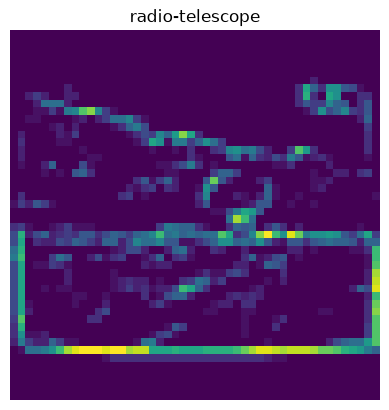

Convolution layer 1


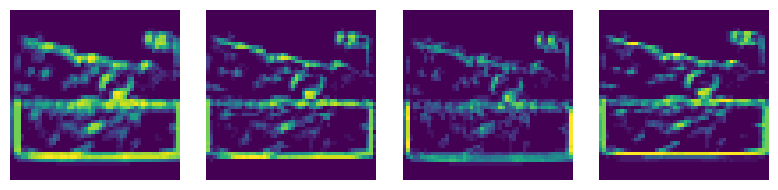

torch.Size([35, 256, 8, 16, 16]) (tensor([0], device='cuda:0'),)
Convolution Layer 2


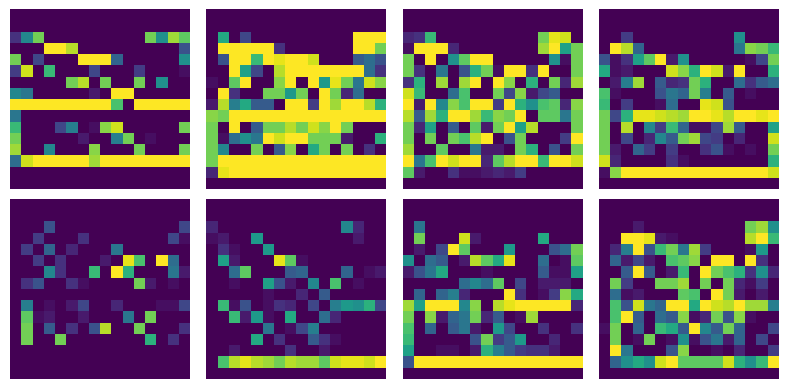

tensor(176, device='cuda:0') tensor(168, device='cuda:0')


In [13]:
model.eval()
sample = next(iter(val_loader))

B, T, H, W = sample['frame'].shape
frames = sample['frame'].float().to(DEVICE)
cats = sample['cat'].to(DEVICE) 

spk_out, mem_rec, fmaps = model(frames)
logits = spk_out.sum(0) # [B,C]

# compute loss
probs = torch.softmax(logits, dim=1)
loss = loss_fn(probs, cats)
print(loss.item())

idx = 10
label = sample['label'][idx]

plt.imshow(sample['frame'].float()[idx].mean(0))
plt.axis('off')
plt.title(label)
plt.show()

all_feature_maps = fmaps[0].mean(dim=0)[idx, :, :, :].squeeze().cpu().detach().numpy()
#all_feature_maps = torch.mean(torch.stack(cur_rec), axis=0)[idx, :, :, :].squeeze().cpu().detach().numpy()
#all_feature_maps = torch.sum(torch.stack(mem_rec), axis=0)[idx, :, :, :].squeeze().cpu().detach().numpy()

print('Convolution layer 1')
fig, axs = plt.subplots(1, 4, sharey=True, sharex=True, figsize=(8, 2))
counter = 0
for j in range(4):
    #print(all_feature_maps[counter].min(), all_feature_maps[counter].max())
    axs[j].imshow(all_feature_maps[counter])
    axs[j].axis('off')
    counter += 1
        
plt.axis('off')
plt.tight_layout()
plt.show()


if len(fmaps) > 1:
    
    print(fmaps[1].shape, torch.where(fmaps[1].mean(dim=0).view(256, -1).argmax()))
    
    all_feature_maps = fmaps[1].sum(dim=0)[idx, :, :, :].squeeze().cpu().detach().numpy()

    print('Convolution Layer 2')

    fig, axs = plt.subplots(2, 4, sharey=True, sharex=True, figsize=(8, 4))
    counter = 0
    for i in range(2):
        for j in range(4):
            #print(all_feature_maps[counter].min(), all_feature_maps[counter].max())
            axs[i, j].imshow(all_feature_maps[counter])
            axs[i, j].axis('off')
            counter += 1

    plt.axis('off')
    plt.tight_layout()
    plt.show()

print(spk_out.sum(dim=0)[idx].argmax(), cats[idx])

## Create Hyperparameter Sweep 

In [11]:
sweep_config = {
    'method': 'random',
    'metric': {
        'name': 'val_accuracy',
        'goal': 'maximize'   
        }
    }

params = {
    'optimizer': {
        'values': ['AdamW']
        },
    'dropout': {
          'values': [0.1, 0.2, 0.3, 0.4, 0.5]
        },
    'surrogate': {
        'values': ['atan', 'fast_sigmoid']
    },
    'lif_threshold': {
        'values': [0.1, 0.3, 0.5]
    },
    'beta': {
        'max': 0.99,
        'min': 0.9,
        'distribution': 'uniform'
    },
    'learning_rate': {
          'max': 0.01,
          'min': 0.0005,
          'distribution': 'uniform'
        },
    'epochs': {
        'value': 10
        }
    }

sweep_config['parameters'] = params

def get_dataloaders(batchsize):
    
    T = transforms.Compose([transforms.ToTensor(),
                            transforms.Pad((0, 30, 0, 30)), #left, top, right, bottom
                            transforms.Resize((48, 48), interpolation=transforms.InterpolationMode.BILINEAR)])

    dataset = CaltechDataset(df, transform=T)

    train_set, val_set = torch.utils.data.random_split(dataset, [int(len(dataset) * 0.8), len(dataset) - int(len(dataset) * 0.8)])
    val_set, test_set = torch.utils.data.random_split(val_set, [int(len(val_set) * 0.8), len(val_set) - int(len(val_set) * 0.8)])
    print('Training samples: ',len(train_set))
    print('Validation samples: ', len(val_set))
    print('Test samples: ', len(test_set))

    train_loader = DataLoader(train_set, batch_size=batchsize, shuffle=True, num_workers=16)
    val_loader = DataLoader(val_set, batch_size=batchsize//2, shuffle=False, num_workers=8)

    return train_loader, val_loader

def train(config=None):
    # Initialize a new wandb run
    with wandb.init(config=config):
        # If called by wandb.agent, as below,
        # this config will be set by Sweep Controller
        config = wandb.config
        
        torch.manual_seed(RANDOM_SEED)

        train_loader, val_loader = get_dataloaders(BATCH_SIZE)

        # surrogate gradient
        spike_grad = getattr(surrogate, config.surrogate)()
        
        model = SpikingObjectClassifier(img_size=(48, 48), n_classes=257, spike_grad=spike_grad, 
                                        dropout=config.dropout, hidden_channels=4)
        model.to(DEVICE)
        
        loss_fn = nn.CrossEntropyLoss() 
        optimizer = getattr(torch.optim, config.optimizer)(model.parameters(), lr=config.learning_rate)
        
        for epoch in range(config.epochs):
    
            train_loss = []
            train_accuracy = []
            
            model.train()

            for batch_idx, batch in enumerate(train_loader):
                optimizer.zero_grad()
                
                B, T, H, W = batch['frame'].shape
                frames = batch['frame'].float().to(DEVICE)
                cats = batch['cat'].to(DEVICE) 
                
                spk_out, mem_rec, _ = model(frames)
        
                logits = spk_out.sum(0) # [B,C]
                probs = torch.softmax(logits, dim=1)
                loss = loss_fn(probs, cats)
        
                loss.backward()
                optimizer.step()

                # log train loss 
                train_loss.append(loss.item())

                # compute train accuracy
                preds = logits.argmax(dim=1)
                acc = (preds == cats).sum().item()
                train_accuracy.append(acc / B)

                
            # Validation
            model.eval()
            val_loss = []
            val_accuracy = []
            with torch.no_grad():
                for batch_idx, batch in enumerate(val_loader):

                    B, T, H, W = batch['frame'].shape
                    frames = batch['frame'].float().to(DEVICE)
                    cats = batch['cat'].to(DEVICE) 

                    spk_out, mem_rec, _ = model(frames)

                    logits = spk_out.sum(0) # [B,C]
                    probs = torch.softmax(logits, dim=1)
                    loss = loss_fn(probs, cats)
        
                    val_loss.append(loss.item())
                    
                    # compute validation accuracy
                    preds = logits.argmax(dim=1)
                    acc = (preds == cats).sum().item()
                    val_accuracy.append(acc / B)
                        
            # log metrics to wandb
            wandb.log({'train_loss': np.mean(train_loss), 'train_accuracy': np.mean(train_accuracy),
                       'val_loss': np.mean(val_loss), 'val_accuracy': np.mean(val_accuracy), 'epoch': epoch}) 
            """
            # log feature maps from last validation batch
            for idx, maps in enumerate(fmaps): 
                maps = maps.sum(dim=0)
                best_idx = maps.view(maps.shape[0], -1).sum(dim=-1).argmax() # best sample 
                i = np.random.choice(maps[best_idx].shape[0]) # pick random feature map 
                bmap = maps[best_idx][i].squeeze().cpu().detach().numpy()
                wandb_images = wandb.Image(bmap, caption=f'Feature Maps - Layer {2+idx}: {bmap.shape[-1]}x{bmap.shape[-1]}')
                wandb.log({f'Feature Maps {idx}': wandb_images})
            """

In [12]:
RANDOM_SEED = 7
BATCH_SIZE = 1024
        
seed_everything(RANDOM_SEED)

sweep_id = wandb.sweep(sweep_config, project="RoDeO")
wandb.agent(sweep_id, train, count=20)

Global seed set to 7


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/penzkofer/.netrc.


Create sweep with ID: abzpxlpc
Sweep URL: https://wandb.ai/apenzko/RoDeO/sweeps/abzpxlpc


wandb: Agent Starting Run: pt1eb8va with config:
wandb: 	beta: 0.9288555721874286
wandb: 	dropout: 0.1
wandb: 	epochs: 10
wandb: 	learning_rate: 0.005182677324193599
wandb: 	lif_threshold: 0.1
wandb: 	optimizer: AdamW
wandb: 	surrogate: fast_sigmoid
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/penzkofer/.netrc.
wandb: Currently logged in as: apenzko to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Training samples:  24485
Validation samples:  4897
Test samples:  1225


...

Training samples:  24485
Validation samples:  4897
Test samples:  1225


epoch,▁▂▃▃▄▅▆▆▇█
train_accuracy,▁▄▆▆▇▇▇▇██
train_loss,█▆▄▃▃▂▂▂▁▁
val_accuracy,▁▅▇▆▇▇▇███
val_loss,█▄▃▂▂▂▁▁▁▁
epoch,9
train_accuracy,0.11794
train_loss,5.43948
val_accuracy,0.10957
val_loss,5.44828


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: jwe0mthz with config:
wandb: 	beta: 0.9044726651423814
wandb: 	dropout: 0.5
wandb: 	epochs: 10
wandb: 	learning_rate: 0.007391856881999337
wandb: 	lif_threshold: 0.5
wandb: 	optimizer: AdamW
wandb: 	surrogate: atan
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/penzkofer/.netrc.


Training samples:  24485
Validation samples:  4897
Test samples:  1225


epoch,▁▂▃▃▄▅▆▆▇█
train_accuracy,▁▄▆▆▇▇▇▇██
train_loss,█▅▃▃▂▂▂▂▁▁
val_accuracy,▁▃▅▄█▅▇▆▇█
val_loss,█▆▅▅▂▃▂▂▁▁
epoch,9
train_accuracy,0.10367
train_loss,5.45345
val_accuracy,0.10092
val_loss,5.4554


## Check feature maps

In [22]:
model.eval()
sample = next(iter(val_loader))

B, T, H, W = sample['frame'].shape
#frames = sample['frame'].float().view(T, B, -1).to(DEVICE)
frames = sample['frame'].float().to(DEVICE)
cats = sample['cat'].to(DEVICE) 

spk_out, mem_rec, fmaps = model(frames)
logits = spk_out.sum(0) # [B,C]

# compute loss
probs = torch.softmax(logits, dim=1)
loss = loss_fn(probs, cats)

In [23]:
idx = 0
test_loss = nn.CrossEntropyLoss()
#input = torch.randn(3, 5, requires_grad=True)
#target = torch.randn(3, 5).softmax(dim=1)
output = test_loss(probs[idx], cats[idx])
print(output)
#output.backward()

tensor(2.5405, device='cuda:0', grad_fn=<NllLossBackward0>)


In [24]:
spk_out.sum(dim=0)[idx, :].argmax(), cats[idx]

(tensor(2, device='cuda:0'), tensor(5, device='cuda:0'))

In [25]:
#for idx in range(10):
idx = 2
print(spk_out.sum(dim=0)[idx].cpu().detach().numpy(), spk_out.sum(dim=0)[idx].argmax(), cats[idx])

[ 0.  0.  0. 28.  0.  2.  0.  0.  0.  0.  0.  0.  0.  0.  0.] tensor(3, device='cuda:0') tensor(11, device='cuda:0')


In [26]:
for idx, maps in enumerate(fmaps):
    maps = maps.sum(dim=0)
    best_idx = maps.view(maps.shape[0], -1).sum(dim=-1).argmax() # best sample 
    i = np.random.choice(maps[best_idx].shape[0])
    best_map = maps[best_idx][i].squeeze().cpu().detach().numpy()
    print(maps.shape, maps[best_idx].shape, i, best_map.shape)

torch.Size([32, 32, 48, 48]) torch.Size([32, 48, 48]) 15 (48, 48)
torch.Size([32, 64, 24, 24]) torch.Size([64, 24, 24]) 4 (24, 24)
torch.Size([32, 64, 12, 12]) torch.Size([64, 12, 12]) 25 (12, 12)


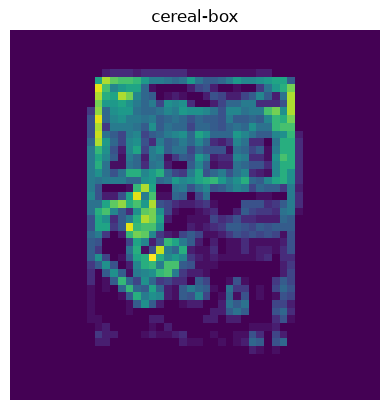

Convolution layer 1


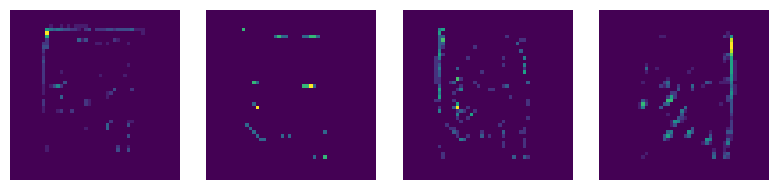

torch.Size([35, 32, 64, 24, 24]) (tensor([0], device='cuda:0'),)
Convolution Layer 2


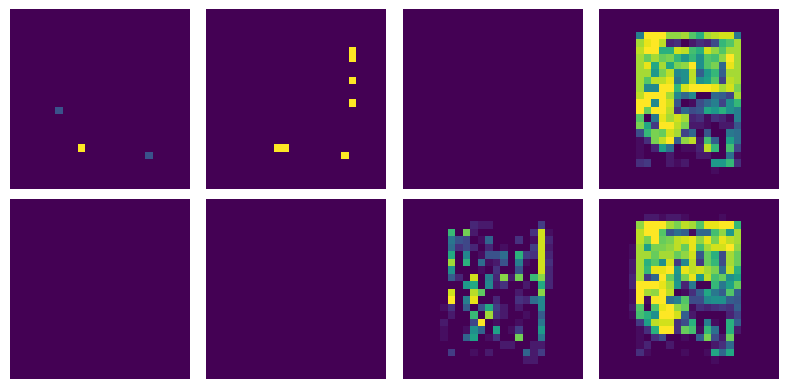

tensor(0, device='cuda:0') tensor(4, device='cuda:0')


In [27]:
model.eval()
sample = next(iter(val_loader))

B, T, H, W = sample['frame'].shape
#frames = sample['frame'].float().view(T, B, -1).to(DEVICE)
frames = sample['frame'].float().to(DEVICE)
cats = sample['cat'].to(DEVICE) 

spk_out, mem_rec, fmaps = model(frames)
logits = spk_out.sum(0) # [B,C]

# compute loss
probs = torch.softmax(logits, dim=1)
loss = loss_fn(probs, cats)

idx = 1
label = sample['label'][idx]

plt.imshow(sample['frame'].float()[idx].mean(0))
plt.axis('off')
plt.title(label)
plt.show()

all_feature_maps = fmaps[0].mean(dim=0)[idx, :, :, :].squeeze().cpu().detach().numpy()
#all_feature_maps = torch.mean(torch.stack(cur_rec), axis=0)[idx, :, :, :].squeeze().cpu().detach().numpy()
#all_feature_maps = torch.sum(torch.stack(mem_rec), axis=0)[idx, :, :, :].squeeze().cpu().detach().numpy()

print('Convolution layer 1')
fig, axs = plt.subplots(1, 4, sharey=True, sharex=True, figsize=(8, 2))
counter = 0
for j in range(4):
    #print(all_feature_maps[counter].min(), all_feature_maps[counter].max())
    axs[j].imshow(all_feature_maps[counter])
    axs[j].axis('off')
    counter += 1
        
plt.axis('off')
plt.tight_layout()
plt.show()


if len(fmaps) > 1:
    
    print(fmaps[1].shape, torch.where(fmaps[1].mean(dim=0).view(256, -1).argmax()))
    
    all_feature_maps = fmaps[1].sum(dim=0)[idx, :, :, :].squeeze().cpu().detach().numpy()

    print('Convolution Layer 2')

    fig, axs = plt.subplots(2, 4, sharey=True, sharex=True, figsize=(8, 4))
    counter = 0
    for i in range(2):
        for j in range(4):
            #print(all_feature_maps[counter].min(), all_feature_maps[counter].max())
            axs[i, j].imshow(all_feature_maps[counter])
            axs[i, j].axis('off')
            counter += 1

    plt.axis('off')
    plt.tight_layout()
    plt.show()

print(spk_out.sum(dim=0)[idx].argmax(), cats[idx])

(tensor([0., 6., 0., 1., 0., 6., 3., 4., 7., 0., 1., 0., 4., 0., 6.],
        device='cuda:0', grad_fn=<SelectBackward0>),
 tensor(8, device='cuda:0'),
 tensor(9, device='cuda:0'))